In [6]:
import sys
import torch
import torchvision

print("Python path:", sys.executable)
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Python path: /opt/anaconda3/envs/cnn_api/bin/python
PyTorch version: 2.2.2
Torchvision version: 0.17.2
Using device: cpu


In [7]:
%%writefile gan_model.py
import torch
from torch import nn


class Generator(nn.Module):
    """
    Input:
        Noise vector: (batch_size, 100)

    Output:
        Generated MNIST image: (batch_size, 1, 28, 28)
    """

    def __init__(self, latent_dim: int = 100):
        super().__init__()

        self.latent_dim = latent_dim

        # 100 -> 7 * 7 * 128
        self.fc = nn.Linear(latent_dim, 7 * 7 * 128)

        # 128 x 7 x 7 -> 64 x 14 x 14
        self.deconv1 = nn.ConvTranspose2d(
            in_channels=128,
            out_channels=64,
            kernel_size=4,
            stride=2,
            padding=1
        )
        self.batch_norm = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()

        # 64 x 14 x 14 -> 1 x 28 x 28
        self.deconv2 = nn.ConvTranspose2d(
            in_channels=64,
            out_channels=1,
            kernel_size=4,
            stride=2,
            padding=1
        )
        self.tanh = nn.Tanh()

    def forward(self, noise: torch.Tensor) -> torch.Tensor:
        x = self.fc(noise)

        # Reshape to batch_size x 128 x 7 x 7
        x = x.view(-1, 128, 7, 7)

        x = self.deconv1(x)
        x = self.batch_norm(x)
        x = self.relu(x)

        x = self.deconv2(x)
        x = self.tanh(x)

        return x


class Discriminator(nn.Module):
    """
    Input:
        MNIST image: (batch_size, 1, 28, 28)

    Output:
        Real/fake probability: (batch_size, 1)
    """

    def __init__(self):
        super().__init__()

        # 1 x 28 x 28 -> 64 x 14 x 14
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=4,
            stride=2,
            padding=1
        )
        self.leaky_relu1 = nn.LeakyReLU(
            negative_slope=0.2
        )

        # 64 x 14 x 14 -> 128 x 7 x 7
        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=4,
            stride=2,
            padding=1
        )
        self.batch_norm = nn.BatchNorm2d(128)
        self.leaky_relu2 = nn.LeakyReLU(
            negative_slope=0.2
        )

        self.flatten = nn.Flatten()

        # 128 * 7 * 7 -> 1
        self.fc = nn.Linear(128 * 7 * 7, 1)

        # Convert output to probability
        self.sigmoid = nn.Sigmoid()

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        x = self.conv1(image)
        x = self.leaky_relu1(x)

        x = self.conv2(x)
        x = self.batch_norm(x)
        x = self.leaky_relu2(x)

        x = self.flatten(x)
        x = self.fc(x)
        x = self.sigmoid(x)

        return x

Overwriting gan_model.py


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image

from gan_model import Generator, Discriminator


torch.manual_seed(42)

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)


PROJECT_ROOT = Path.cwd()

MODEL_DIR = PROJECT_ROOT / "models"
SAMPLE_DIR = PROJECT_ROOT / "samples"
DATA_DIR = PROJECT_ROOT / "data"

MODEL_DIR.mkdir(exist_ok=True)
SAMPLE_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)

Using device: cpu
Project root: /Users/zuoqinglyu/Downloads/assignment1-word-embedding-api-main


In [9]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

Images shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])
Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [10]:
import torch

from gan_model import Generator, Discriminator

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)
print("Generator imported successfully")

Using device: cpu
Generator imported successfully


In [11]:
LATENT_DIM = 100

generator = Generator(
    latent_dim=LATENT_DIM
).to(device)

discriminator = Discriminator().to(device)

test_noise = torch.randn(
    8,
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    test_images = generator(test_noise)
    test_predictions = discriminator(test_images)

print("Noise shape:", test_noise.shape)
print("Generated images shape:", test_images.shape)
print("Discriminator output shape:", test_predictions.shape)

Noise shape: torch.Size([8, 100])
Generated images shape: torch.Size([8, 1, 28, 28])
Discriminator output shape: torch.Size([8, 1])


In [13]:
LEARNING_RATE = 0.0002

criterion = nn.BCELoss()

generator_optimizer = Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

discriminator_optimizer = Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

fixed_noise = torch.randn(
    64,
    LATENT_DIM,
    device=device
)

print("Loss and optimizers are ready.")

Loss and optimizers are ready.


In [14]:
EPOCHS = 10

generator_losses = []
discriminator_losses = []

for epoch in range(EPOCHS):
    generator.train()
    discriminator.train()

    total_generator_loss = 0
    total_discriminator_loss = 0

    for batch_number, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        real_labels = torch.ones(
            current_batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            current_batch_size,
            1,
            device=device
        )

        # -----------------------------
        # Train Discriminator
        # -----------------------------
        discriminator_optimizer.zero_grad()

        real_predictions = discriminator(real_images)
        real_loss = criterion(
            real_predictions,
            real_labels
        )

        noise = torch.randn(
            current_batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = generator(noise)

        fake_predictions = discriminator(
            fake_images.detach()
        )

        fake_loss = criterion(
            fake_predictions,
            fake_labels
        )

        discriminator_loss = (
            real_loss + fake_loss
        ) / 2

        discriminator_loss.backward()
        discriminator_optimizer.step()

        # -----------------------------
        # Train Generator
        # -----------------------------
        generator_optimizer.zero_grad()

        generator_predictions = discriminator(
            fake_images
        )

        generator_loss = criterion(
            generator_predictions,
            real_labels
        )

        generator_loss.backward()
        generator_optimizer.step()

        total_discriminator_loss += discriminator_loss.item()
        total_generator_loss += generator_loss.item()

        if batch_number % 100 == 0:
            print(
                f"Epoch [{epoch + 1}/{EPOCHS}] "
                f"Batch [{batch_number}/{len(train_loader)}] "
                f"D Loss: {discriminator_loss.item():.4f} "
                f"G Loss: {generator_loss.item():.4f}"
            )

    average_discriminator_loss = (
        total_discriminator_loss / len(train_loader)
    )

    average_generator_loss = (
        total_generator_loss / len(train_loader)
    )

    discriminator_losses.append(
        average_discriminator_loss
    )

    generator_losses.append(
        average_generator_loss
    )

    print(
        f"Epoch {epoch + 1} finished | "
        f"Average D Loss: {average_discriminator_loss:.4f} | "
        f"Average G Loss: {average_generator_loss:.4f}"
    )

    generator.eval()

    with torch.no_grad():
        sample_images = generator(fixed_noise)

    save_image(
        sample_images,
        SAMPLE_DIR / f"epoch_{epoch + 1}.png",
        nrow=8,
        normalize=True,
        value_range=(-1, 1)
    )

Epoch [1/10] Batch [0/469] D Loss: 0.7329 G Loss: 0.9260
Epoch [1/10] Batch [100/469] D Loss: 0.2078 G Loss: 1.2003
Epoch [1/10] Batch [200/469] D Loss: 0.2222 G Loss: 1.3937
Epoch [1/10] Batch [300/469] D Loss: 0.1563 G Loss: 2.0113
Epoch [1/10] Batch [400/469] D Loss: 0.1240 G Loss: 2.2237
Epoch 1 finished | Average D Loss: 0.1963 | Average G Loss: 2.1658
Epoch [2/10] Batch [0/469] D Loss: 0.2429 G Loss: 4.3133
Epoch [2/10] Batch [100/469] D Loss: 0.1498 G Loss: 1.5015
Epoch [2/10] Batch [200/469] D Loss: 0.1351 G Loss: 2.1103
Epoch [2/10] Batch [300/469] D Loss: 0.1671 G Loss: 2.2176
Epoch [2/10] Batch [400/469] D Loss: 0.3257 G Loss: 5.2622
Epoch 2 finished | Average D Loss: 0.1802 | Average G Loss: 2.4215
Epoch [3/10] Batch [0/469] D Loss: 0.1351 G Loss: 2.5670
Epoch [3/10] Batch [100/469] D Loss: 0.1617 G Loss: 2.2329
Epoch [3/10] Batch [200/469] D Loss: 0.1533 G Loss: 1.7909
Epoch [3/10] Batch [300/469] D Loss: 0.3556 G Loss: 4.2968
Epoch [3/10] Batch [400/469] D Loss: 0.1759 G 

In [15]:
generator_path = MODEL_DIR / "mnist_generator.pth"
discriminator_path = MODEL_DIR / "mnist_discriminator.pth"

torch.save(
    generator.state_dict(),
    generator_path
)

torch.save(
    discriminator.state_dict(),
    discriminator_path
)

print("Generator saved to:", generator_path)
print("Discriminator saved to:", discriminator_path)

Generator saved to: /Users/zuoqinglyu/Downloads/assignment1-word-embedding-api-main/models/mnist_generator.pth
Discriminator saved to: /Users/zuoqinglyu/Downloads/assignment1-word-embedding-api-main/models/mnist_discriminator.pth


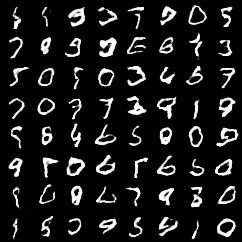

In [16]:
from IPython.display import display, Image

display(
    Image(
        filename=str(
            SAMPLE_DIR / "epoch_10.png"
        )
    )
)